# Final problem

We will do two exercises:

1. Create a film recommendation system using word embeddings:
    - Explain how would you create a recommendation system for films using word embeddings. Which variables would you use? How to represent the data? Which techniques/algorithms would you use to represent the films and to compute similarities between them? Dataset: You can use the [Wikipedia Movie Plots dataset](https://www.kaggle.com/datasets/jrobischon/wikipedia-movie-plots).
2. Sentiment analysis of film reviews:
    - Explain how would you create a sentiment analysis model for film reviews. How would you preprocess the data? How would you represent the reviews? Which model architecture would you choose and why? How would you evaluate the model's performance? Dataset: You can use the [IMDb movie reviews dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).

In [31]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer, TFBertModel
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/javier/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/javier/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/javier/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Film recommendation system using word embeddings

### 1.1 Loading the dataset

In [32]:
movie_plots_dataset = pd.read_csv('datasets/wiki_movie_plots_deduped.csv')
movie_plots_dataset.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot
0,1901,Kansas Saloon Smashers,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Kansas_Saloon_Smashers,"A bartender is working at a saloon, serving drinks to customers. After he fills a stereotypically Irish man's bucket with beer, Carrie Nation and her followers burst inside. They assault the Irish man, pulling his hat over his eyes and then dumping the beer over his head. The group then begin wrecking the bar, smashing the fixtures, mirrors, and breaking the cash register. The bartender then sprays seltzer water in Nation's face before a group of policemen appear and order everybody to leave.[1]"
1,1901,Love by the Light of the Moon,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Love_by_the_Light_of_the_Moon,"The moon, painted with a smiling face hangs over a park at night. A young couple walking past a fence learn on a railing and look up. The moon smiles. They embrace, and the moon's smile gets bigger. They then sit down on a bench by a tree. The moon's view is blocked, causing him to frown. In the last scene, the man fans the woman with his hat because the moon has left the sky and is perched over her shoulder to see everything better."
2,1901,The Martyred Presidents,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/The_Martyred_Presidents,"The film, just over a minute long, is composed of two shots. In the first, a girl sits at the base of an altar or tomb, her face hidden from the camera. At the center of the altar, a viewing portal displays the portraits of three U.S. Presidents—Abraham Lincoln, James A. Garfield, and William McKinley—each victims of assassination.\r\nIn the second shot, which runs just over eight seconds long, an assassin kneels feet of Lady Justice."
3,1901,"Terrible Teddy, the Grizzly King",American,Unknown,NaN,unknown,"https://en.wikipedia.org/wiki/Terrible_Teddy,_the_Grizzly_King","Lasting just 61 seconds and consisting of two shots, the first shot is set in a wood during winter. The actor representing then vice-president Theodore Roosevelt enthusiastically hurries down a hillside towards a tree in the foreground. He falls once, but rights himself and cocks his rifle. Two other men, bearing signs reading ""His Photographer"" and ""His Press Agent"" respectively, follow him into the shot; the photographer sets up his camera. ""Teddy"" aims his rifle upward at the tree and fells what appears to be a common house cat, which he then proceeds to stab. ""Teddy"" holds his prize aloft, and the press agent takes notes. The second shot is taken in a slightly different part of the wood, on a path. ""Teddy"" rides the path on his horse towards the camera and out to the left of the shot, followed closely by the press agent and photographer, still dutifully holding their signs."
4,1902,Jack and the Beanstalk,American,"George S. Fleming, Edwin S. Porter",NaN,unknown,https://en.wikipedia.org/wiki/Jack_and_the_Beanstalk_(1902_film),"The earliest known adaptation of the classic fairytale, this films shows Jack trading his cow for the beans, his mother forcing him to drop them in the front yard, and beig forced upstairs. As he sleeps, Jack is visited by a fairy who shows him glimpses of what will await him when he ascends the bean stalk. In this version, Jack is the son of a deposed king. When Jack wakes up, he finds the beanstalk has grown and he climbs to the top where he enters the giant's home. The giant finds Jack, who narrowly escapes. The giant chases Jack down the bean stalk, but Jack is able to cut it down before the giant can get to safety. He falls and is killed as Jack celebrates. The fairy then reveals that Jack may return home as a prince."


### 1.2. Analysis of the dataset and Cleaning

In [33]:
print(f"dataset size: {movie_plots_dataset.shape}")
print(movie_plots_dataset.columns)
print("Null values per column:")
print(movie_plots_dataset.isnull().sum())
print("Unknown values per column:")
print((movie_plots_dataset == 'unknown').sum())

dataset size: (34886, 8)
Index(['Release Year', 'Title', 'Origin/Ethnicity', 'Director', 'Cast',
       'Genre', 'Wiki Page', 'Plot'],
      dtype='object')
Null values per column:
Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                1422
Genre                  0
Wiki Page              0
Plot                   0
dtype: int64
Unknown values per column:
Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                   0
Genre               6083
Wiki Page              0
Plot                   0
dtype: int64


In [34]:
print("Cast unique values:")
print(len(movie_plots_dataset['Cast'].unique().tolist()))
print("Percentage of 'NaN' values in Cast column:")
print(movie_plots_dataset['Cast'].isna().mean() * 100)

Cast unique values:
32183
Percentage of 'NaN' values in Cast column:
4.07613369259875


In [35]:
print("Genre unique values:")
print(len(movie_plots_dataset['Genre'].unique().tolist()))
print("Percentage of 'unknown' values in Genre column:")
unknown_genre_percentage = movie_plots_dataset['Genre'].str.contains('unknown').sum() / movie_plots_dataset.shape[0] * 100
print(f"{unknown_genre_percentage:.2f}%")

Genre unique values:
2265
Percentage of 'unknown' values in Genre column:
17.44%


In [36]:
print("Release year range:")
print(movie_plots_dataset['Release Year'].min(), "-", movie_plots_dataset['Release Year'].max())

Release year range:
1901 - 2017


In [37]:
print("Origin/Ethnicity unique values:")
print(len(movie_plots_dataset['Origin/Ethnicity'].unique().tolist()))

Origin/Ethnicity unique values:
24


In [38]:
print("Director unique values:")
print(len(movie_plots_dataset['Director'].unique().tolist()))

Director unique values:
12593


From the dataset we have several variables that can be useful for creating a recommendation system. The most relevant ones are:
- Title: The name of the movie.
- Plot: A brief summary of the movie's storyline.
- Genre: The category or categories the movie belongs to (e.g., Action, Comedy, Drama). 17% of 'unknown' values. We could consider dropping rows with unknown genre if we find it relevant. It suffers from multi-label classification as some movies have multiple genres.
- Director: The director of the movie.
- Cast: The main actors in the movie. 4% of NaN values. We could consider dropping rows with unknown cast if we find it relevant.
- Release Year: The year the movie was released. Range goes from 1901 to 2017.
- Origin/Ethnicity: The country or region where the movie was produced. It has only 24 unique values, so it might not provide much variability for recommendations if the user base is diverse.

> Wiki page column can be dropped as it does not provide useful information for recommendations.

In [39]:
movie_plots_dataset = movie_plots_dataset.drop(columns=['Wiki Page'])

As we are focusing on word embeddings, the most relevant variable for this task is the "Plot" column, as it contains textual data that can be effectively represented using word embeddings. Hence, 'unknown' and NaN values in other columns might not be a significant issue for this specific approach, we will just replace with empty strings.

In [40]:
movie_plots_dataset['Genre'] = movie_plots_dataset['Genre'].replace('unknown', '')
movie_plots_dataset['Cast'] = movie_plots_dataset['Cast'].fillna('')

We will train two models, one just using the "Plot" column, and another one using a combination of "Plot", "Genre", "Director", and "Cast" columns(text enrichment). For the second model, we will concatenate the text from these columns into a single string for each movie. This helps embeddings capture style, theme and creators.

> Year and Origin are more useful for filtering the recommendations rather than for representing the movies in the embedding space.

> Title is the identifier of the movie.

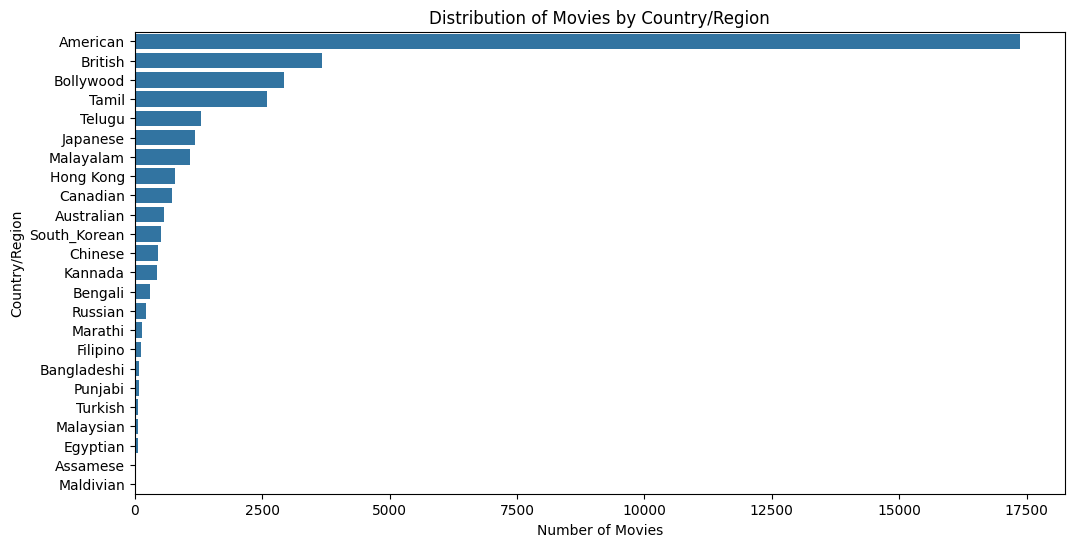

In [41]:
plt.figure(figsize=(12,6))
sns.countplot(y='Origin/Ethnicity', data=movie_plots_dataset, order=movie_plots_dataset['Origin/Ethnicity'].value_counts().index)
plt.title('Distribution of Movies by Country/Region')
plt.xlabel('Number of Movies')
plt.ylabel('Country/Region')
plt.show()

The most represented countries are USA, UK and India.

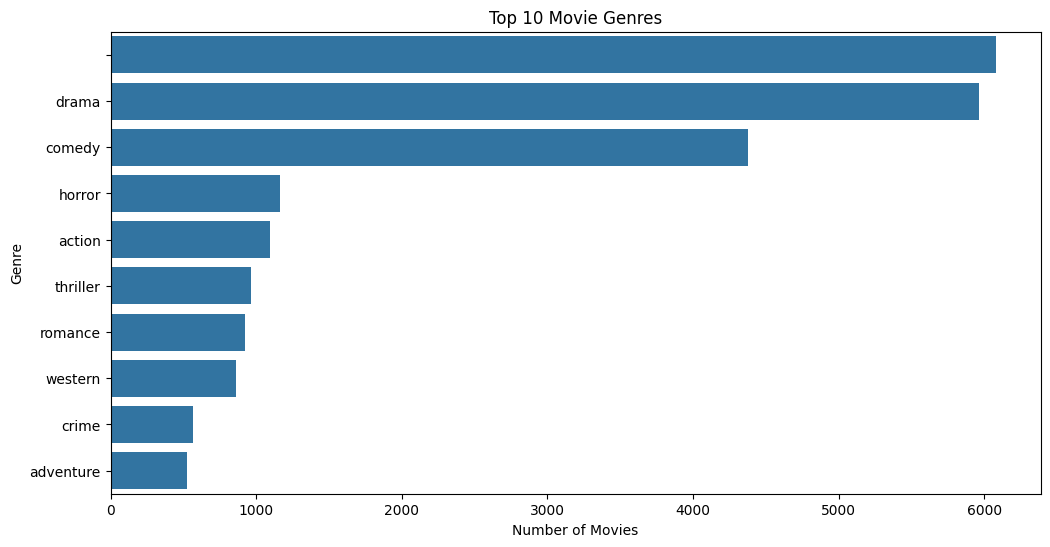

The most used genre is: 


In [42]:
# TOp 10 genres
plt.figure(figsize=(12,6))
sns.countplot(y='Genre', data=movie_plots_dataset, order=movie_plots_dataset['Genre'].value_counts().nlargest(10).index)
plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()
most_used_genre = movie_plots_dataset['Genre'].value_counts().idxmax()
print(f"The most used genre is: {most_used_genre}") 

Ignoring 'unknown' genres, the most used genre is Drama, with Comedy and Horror following.

> Empty genred are not a problem for text enrichment as we will just concatenate an empty string.

We will split the dataset into training and testing sets, using 80% of the data for training and 20% for testing.

In [43]:
movie_plot_training_data, movie_plot_test_data = train_test_split(movie_plots_dataset, test_size=0.2, random_state=42)

### 1.3 Text Preprocessing

In [44]:
def clean_text(text):
    # to string
    text = str(text)
    
    # lower case
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove parentheses and their content
    text = re.sub(r'\(.*?\)', '', text)

    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stop words (Stop words are common words that do not add much meaning to a sentence, such as "i", "me", "myself", etc.)
    stop_words = set(stopwords.words('english'))
    tweet_tokens = nltk.word_tokenize(text)
    filtered_words = [word for word in tweet_tokens if word not in stop_words]
    text = ' '.join(filtered_words)
    
    # Replace contractions
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "'cause": "because",
        "could've": "could have",
        "won't": "will not",
        "wouldn't": "would not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "it's": "it is",
        "i'm": "I am",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are",
        "that's": "that is",
        "there's": "there is",
        "what's": "what is",
        "who's": "who is",
        "couldn't": "could not",
        "shouldn't": "should not",
        "would've": "would have",
        "let's": "let us",
        "imma": "I am going to",
        "im": "I am",
        "Im": "I am",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'s": " is",
        "'t": " not",
        "'m": " am",
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text, flags=re.IGNORECASE)

    return text

In [45]:
movie_plot_training_data['clean_text'] = movie_plot_training_data['Plot'].apply(clean_text)
movie_plot_test_data['clean_text'] = movie_plot_test_data['Plot'].apply(clean_text)

In [46]:
movie_plot_training_data.sample(1)

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Plot,clean_text
11541,1990,Too Much Sun,American,"Robert Downey, Sr.","Robert Downey, Jr., Eric Idle, Ralph Macchio",comedy,"A multi-millionaire is making out his will. His son is gay and his daughter a lesbian, yet he vows to leave his fortune to the first one who can produce a grandchild.",multi millionaire making son gay daughter lesbian yet vows leave fortune first one produce grandchild


> Plot texts have mentions of the actors names between parentheses, we will remove them as they do not add relevant information to the plot description.

In [64]:
print(movie_plot_training_data.clean_text.apply(type).value_counts())
print(movie_plot_training_data.clean_text[movie_plot_training_data.clean_text.apply(lambda x: isinstance(x, float))])
movie_plot_training_data = movie_plot_training_data.dropna(subset=['clean_text'])
movie_plot_training_data['clean_text'] = movie_plot_training_data['clean_text'].astype(str)
print(movie_plot_test_data.clean_text.apply(type).value_counts())
print(movie_plot_test_data.clean_text[movie_plot_test_data.clean_text.apply(lambda x: isinstance(x, float))])
movie_plot_test_data = movie_plot_test_data.dropna(subset=['clean_text'])
movie_plot_test_data['clean_text'] = movie_plot_test_data['clean_text'].astype(str)

clean_text
<class 'str'>    27907
Name: count, dtype: int64
Series([], Name: clean_text, dtype: object)
clean_text
<class 'str'>    6978
Name: count, dtype: int64
Series([], Name: clean_text, dtype: object)


In [65]:
movie_plot_training_data.to_csv('datasets/movie_plot_training_data.csv', index=False)
movie_plot_test_data.to_csv('datasets/movie_plot_test_data.csv', index=False)

In [66]:
movie_plot_training_data = pd.read_csv('datasets/movie_plot_training_data.csv')
movie_plot_test_data = pd.read_csv('datasets/movie_plot_test_data.csv')

### 1.4 Word Embeddings and Similarity Computation

We will use Word2Vec as the word embedding technique for representing the movie plots. Word2Vec is effective in capturing semantic relationships between words, which is crucial for understanding the context of movie plots.

A vector size of 300 dimensions will be used, as it provides a good balance between capturing semantic information and computational efficiency. The window size will be set to 5, allowing the model to consider a reasonable context around each word. A minimum word count of 2 will be used to filter out infrequent words that may not contribute significantly to the embeddings.

In [88]:
texts = movie_plot_training_data['clean_text'].apply(preprocess_string).tolist()
word2vec_movie_plot_model = Word2Vec(sentences=texts, vector_size=300, window=5, min_count=2, workers=1)
word2vec_movie_plot_model.save("models/word2vec_movie_plot_model.model")

Let's test the embedding quality

In [89]:
word_vectors = word2vec_movie_plot_model.wv
similarity = word_vectors.similarity('horror', 'monster')
print(f"Similarity between 'horror' and 'monster': {similarity}")

# similarity = word_vectors.similarity('comedy', 'funny')
# print(f"Similarity between 'comedy' and 'funny': {similarity}")

# similarity = word_vectors.similarity('action', 'adventure')
# print(f"Similarity between 'action' and 'adventure': {similarity}")

# similarity = word_vectors.similarity('romance', 'love')
# print(f"Similarity between 'romance' and 'love': {similarity}")

Similarity between 'horror' and 'monster': 0.4994235336780548


Horror and monster have a similarity of 0.5 which is reasonable but not very high. This could be due to the fact that while they are related concepts, they are not synonymous. Other pairs tried returned errors due to words not being in the vocabulary, this could be solved by enriching the training data with other columns.

> For movie recommendation, we don’t care about word-word similarity. You care about movie-movie similarity,

### 1.5 Calculate Movie Embeddings
Now that we have a trained Word2Vec model, we can compute the embeddings for each movie by averaging the word vectors of all words in the movie's plot description. This will give us a fixed-size vector representation for each movie.

In [90]:
def movie_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

movie_vectors = np.array([movie_vector(preprocess_string(str(text)), word2vec_movie_plot_model)
                          for text in movie_plot_training_data['clean_text']])

Then we build the recommendation system based on cosine similarity

In [91]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(movie_vectors)


And finally we can test the recommendation system

In [95]:
def recommend_movies(movie_index, similarity_matrix, movie_titles, top_n=5):
    similarity_scores = list(enumerate(similarity_matrix[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n+1]
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = movie_titles.iloc[recommended_movie_indices]
    return recommended_movies

movie_titles = movie_plot_training_data['Title']
movie_index = 0  # Index of the movie for which we want recommendations
recommended_movies = recommend_movies(movie_index, similarity_matrix, movie_titles, top_n=5)
print(f"Movies similar to '{movie_titles.iloc[movie_index]}':")
for i, title in enumerate(recommended_movies, start=1):
    print(f"{i}. {title}")

Movies similar to 'Care Bears !The Care Bears' Big Wish Movie':
1. The Care Bears Movie
2. Care Bears: Journey to Joke-a-lot
3. Eiga Tamagotchi: Himitsu no Otodake Daisakusen!
4. Crayon Shin-chan: Fast Asleep! The Great Assault on Dreamy World!
5. Care Bears Movie II: A New Generation


In [94]:
def ask_movies(movie_name, similarity_matrix, movie_titles, top_n=5):
    try:
        movie_index = movie_titles[movie_titles == movie_name].index[0]
    except IndexError:
        print(f"Movie '{movie_name}' not found in the dataset.")
        return []
    
    similarity_scores = list(enumerate(similarity_matrix[movie_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = similarity_scores[1:top_n+1]
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = movie_titles.iloc[recommended_movie_indices]
    return recommended_movies

In [106]:
ask_movies("The Lord of the Rings", similarity_matrix, movie_titles, top_n=5)

14244                          The Lord of the Rings: The Fellowship of the Ring
11264                                      The Lord of the Rings: The Two Towers
13943                                                     The Return of the King
22458    Hobbit: The Desolation of Smaug, TheThe Hobbit: The Desolation of Smaug
23622                                              Kingsglaive: Final Fantasy XV
Name: Title, dtype: object

## 2. Sentiment analysis of film reviews

### 2.1 Loading the dataset

In [107]:
movie_reviews_dataset = pd.read_csv('datasets/IMDB Dataset.csv')
movie_reviews_dataset.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom